# V26: Threshold Optimization with Transaction Cost Accounting

This notebook builds upon V23/V25 by incorporating **Transaction Costs (Fees)** into the backtest simulation. 
In real trading, rebalancing assets and switching between Risk-On/Risk-Off incurs costs that can significantly impact net performance.

### Added Features:
1. **Transaction Cost Model**: Applied a fee (default 0.1%) every time weights change.
2. **Threshold Optimization**: Still using F0.5-Score on Training Data.
3. **Realistic Net Returns**: Comparison of strategies after fees.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'dataset_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = '../dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 990 rows


In [2]:
# --- 2. Threshold Optimization Function ---

def find_optimal_threshold(model, X, y, beta=0.5):
    probs = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.3, 0.8, 51)
    scores = [fbeta_score(y, (probs >= t).astype(int), beta=beta) for t in thresholds]
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]

# --- 3. Model Training ---
print("Training AI Gatekeepers...")

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_opt_t, _ = find_optimal_threshold(rf_model, X_train, y_train)
rf_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_opt_t, _ = find_optimal_threshold(xgb_model, X_train, y_train)
xgb_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Thresholds: RF={rf_opt_t:.2f}, XGB={xgb_opt_t:.2f}")
print("✓ Training Complete.")

Training AI Gatekeepers...
Optimized Thresholds: RF=0.37, XGB=0.60
✓ Training Complete.


In [3]:
# --- 4. Core Logic with Transaction Costs ---

def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, fee=0.001, lookback=30, cor_t=0.5):
    """
    Simulation with Transaction Fee (fee=0.001 represents 0.1%)
    """
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    prev_weights = {}
    
    for i, date in enumerate(test_dates[:-1]):
        # 1. Decision Logic
        if strategy_type == 'Markowitz Only':
            is_risk_off = False
        else:
            is_risk_off = ai_probs.loc[date] < threshold
        
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        if is_risk_off:
            weights = {'CASH': 1.0}
        else:
            if 'Graph' in strategy_type:
                selected = get_mis_assets(window_rets, correlation_threshold=cor_t)
                weights = optimize_markowitz(window_rets[selected])
            else:
                weights = optimize_markowitz(window_rets)
        
        # 2. Transaction Cost calculation
        # Total cost is the sum of absolute changes in all asset weights (including cash)
        all_adj_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_adj_assets)
        cost = val * turnover * fee
        
        val -= cost
        
        # 3. PnL Calculation
        next_date = test_dates[i+1]
        next_rets = returns.loc[next_date]
        
        day_ret = 0 if 'CASH' in weights else sum(w * next_rets[a] for a, w in weights.items())
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

In [4]:
# --- 5. Backtest Execution ---
test_dates = rf_probs.index
transaction_fee = 0.001 # 0.1% per turnover

results = {}
sim_configs = [
    ('Markowitz Only', 'Markowitz Only', None, 0.5),
    ('AI+Graph Opt', 'RF + Graph (Opt T + Fee)', rf_probs, rf_opt_t),
    ('AI+Graph Opt', 'XGB + Graph (Opt T + Fee)', xgb_probs, xgb_opt_t),
    ('BTC', 'Buy and Hold (BTC)', None, 0)
]

for s_type, label, probs, t_val in sim_configs:
    if s_type == 'BTC':
        btc = data.loc[test_dates, 'BTC-USD']
        results[label] = pd.DataFrame({'Portfolio_Value': (btc / btc.iloc[0] * 100)}, index=test_dates)
    else:
        print(f"Running sim: {label}...")
        results[label] = run_simulation(s_type, test_dates, returns, probs, threshold=t_val, fee=transaction_fee)

print("✓ Simulations with Transaction Costs Finished.")

Running sim: Markowitz Only...
Running sim: RF + Graph (Opt T + Fee)...
Running sim: XGB + Graph (Opt T + Fee)...
✓ Simulations with Transaction Costs Finished.


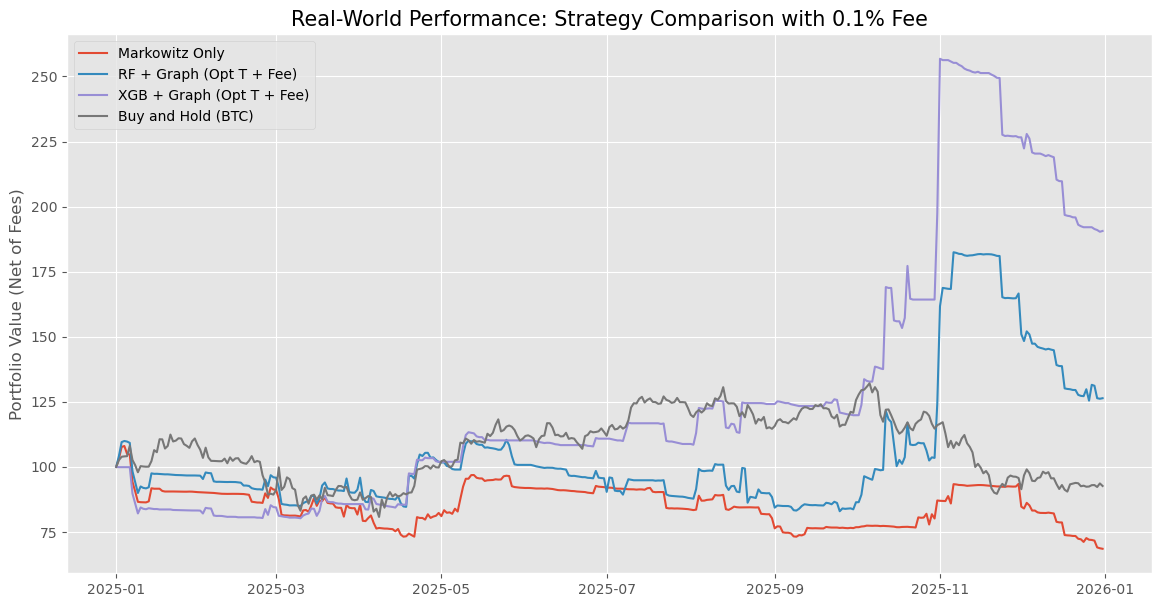

                    Strategy Total Return  Sharpe    MaxDD
0             Markowitz Only      -31.45%   -0.68  -36.55%
1   RF + Graph (Opt T + Fee)       26.40%    0.55  -31.24%
2  XGB + Graph (Opt T + Fee)       90.66%    1.15  -25.88%
3         Buy and Hold (BTC)       -7.32%    0.02  -32.15%


In [5]:
# --- 6. Results Visualization ---
plt.figure(figsize=(14, 7))
for label, df in results.items():
    plt.plot(df.index, df['Portfolio_Value'], label=label)

plt.title(f"Real-World Performance: Strategy Comparison with {transaction_fee*100}% Fee", fontsize=15)
plt.ylabel("Portfolio Value (Net of Fees)")
plt.legend()
plt.grid(True)
plt.savefig('v26_backtest_with_fees.png', dpi=300)
plt.show()

# Metrics Table
summary = []
for label, df in results.items():
    ret = df['Portfolio_Value'].pct_change().dropna()
    total_ret = (df['Portfolio_Value'].iloc[-1] / 100) - 1
    sharpe = (ret.mean() * 252) / (ret.std() * np.sqrt(252))
    drawdown = (df['Portfolio_Value'] / df['Portfolio_Value'].cummax() - 1).min()
    summary.append({'Strategy': label, 'Total Return': f"{total_ret:.2%}", 'Sharpe': round(sharpe, 2), 'MaxDD': f"{drawdown:.2%}"})

print(pd.DataFrame(summary))